# Lab 3

## Task 1

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
import pandas as pd

df = pd.read_csv('./global-electricity-consumption.csv')
df.head()

,Country,1992,1993,1994,1995,1996,1997,1998,1999,2000,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Algeria,14.035,14.039,14.365,14.474,15.172,15.365,16.905,18.492,19.71552,...,42.86750,45.20140,49.205720,53.45544,55.823040,60.283460,62.114030,66.646000,63.694903,68.663379
1,Angola,1.013,1.062,1.071,1.074,1.085,1.216,1.328,1.106,1.19302,...,5.33508,7.05006,8.148660,8.23114,9.036511,9.468667,11.384079,13.658591,14.754764,14.560491
2,Benin,0.229,0.221,0.252,0.242,0.2787,0.2797,0.2707,0.3147,0.39008,...,0.93312,0.93648,0.933660,1.08156,1.061040,1.125821,1.187964,0.929700,0.524080,0.523383
3,Botswana,1.09184,1.11411,1.28092,1.31371,1.39087,1.5571,1.571,1.749,1.71218,...,3.20900,3.34768,3.605280,3.73004,3.615840,3.552800,3.651212,4.162138,3.222130,3.353038
4,Burkina Faso,0.1767,0.19065,0.19158,0.21576,0.24459,0.26226,0.29016,0.32364,0.269,...,1.24784,1.35648,1.431962,1.69966,1.997400,2.067920,2.264800,2.651386,2.467133,2.642688


In [79]:
countries = np.genfromtxt(
    './global-electricity-consumption.csv', usecols=[0], skip_header=1, delimiter=',', dtype=str)

consumption = np.genfromtxt('./global-electricity-consumption.csv', skip_header=1, delimiter=',')
consumption = consumption[:, 1:]

generation = np.genfromtxt('./global-electricity-generation.csv', skip_header=1, delimiter=',')
generation = generation[:, 1:]

In [80]:
average_generation = np.mean(generation[:, -5:], axis=1)
average_consumption = np.mean(consumption[:, -5:], axis=1)
# print(f'{average_consumption=}, {average_generation=}')

In [96]:
# 3.1. Суммарное (по всем странам) потребление электроэнергии за каждый год.
total_over_year = np.nansum(consumption, axis=0)
round_2 = lambda x: round(x, 2)
format_np = lambda x: map(round_2, map(float, x))
print(f'Total of all countries over years:\n'
      + '\n'.join(map(str, zip(range(1992, 2022), format_np(total_over_year)))), '\n')

# 3.2. Максимальное количество электроэнергии, которое произвела одна страна за
# один год (указание: чтобы не учитывать отсутствующие и некорректные данные
# (nan) воспользуйтесь NaN-безопасной версией функции max, то есть nanmax).
max_generation = np.nanmax(generation)
print("Max generetion in history", max_generation, '\n')

# 3.3. Список стран, которые производят более 500 млрд. кВт*ч электроэнергии
# ежегодно в среднем за последние 5 лет (воспользуйтесь массивом, полученным на
# шаге 2).
countries_above_500_gen_past_5y = \
    list(map(str, countries[np.where(average_generation > 500)]))
print("Generated more than 500 in every past 5 years", countries_above_500_gen_past_5y, '\n')

# 3.4. 10% стран, которые потребляют больше всего электроэнергии ежегодно в
# среднем за последние 5 лет (указание: вначале определите соответствующую
# квантиль в массиве, построенном на шаге 2).
idx = np.where(average_consumption > np.nanpercentile(average_consumption, 90))
countries_top10_consumption = countries[idx]
print("Over top 10% consumers: ", countries_top10_consumption, '\n')

# 3.5. Список стран, которые увеличили производство электроэнергии в 2021 году по
# сравнению с 1992 годом более, чем в 10 раз.
increase_countries = countries[(generation[:, -1] > 10 * generation[:, 0])]
print("Increased consumption in more than 10 time countries: ", increase_countries, '\n')

# 3.6. Список стран, которые в сумме за все годы потратили больше 100 млрд. кВт*ч
# электроэнергии и при этом произвели меньше, чем потратили.
total_consumption = np.nansum(consumption, axis=1)
total_generation = np.nansum(generation, axis=1)
countries_consume_more100_neg_delta = countries[(total_consumption > 100) & (total_consumption > total_generation)]
print("Consumed more 100 and generated lower than consumed: ", countries_consume_more100_neg_delta, '\n')

# 3.7. Какая страна потратила наибольшее количество электроэнергии в 2020 году?
print("Top 1 consumer country of 2020: ", countries[np.argmax(consumption[:, -2])])

Total of all countries over years:
(1992, 10569.02)
(1993, 10854.56)
(1994, 11104.65)
(1995, 11476.48)
(1996, 11805.87)
(1997, 12122.03)
(1998, 12419.81)
(1999, 12685.75)
(2000, 13230.25)
(2001, 13486.49)
(2002, 13938.78)
(2003, 14455.56)
(2004, 15128.1)
(2005, 15725.98)
(2006, 16438.21)
(2007, 17205.12)
(2008, 17477.47)
(2009, 17435.69)
(2010, 18748.16)
(2011, 19438.82)
(2012, 19918.25)
(2013, 20573.1)
(2014, 20981.24)
(2015, 21400.02)
(2016, 22022.69)
(2017, 22716.21)
(2018, 23530.92)
(2019, 23915.66)
(2020, 23959.68)
(2021, 25336.71) 

Max generetion in history 8151.518231 

Generated more than 500 in every past 5 years ['Russia', 'France', 'Germany', 'China', 'India', 'Japan', 'South Korea', 'Canada', 'United States', 'Brazil'] 

Over top 10% consumers:  ['South Africa' 'Russia' 'France' 'Germany' 'Italy' 'Spain' 'Turkiye'
 'United Kingdom' 'Australia' 'China' 'India' 'Indonesia' 'Japan'
 'South Korea' 'Taiwan' 'Vietnam' 'Iran' 'Saudi Arabia' 'Canada' 'Mexico'
 'United States' 'Bra

## Task 2

!!!! это надо проверить !!!!!!!!!!

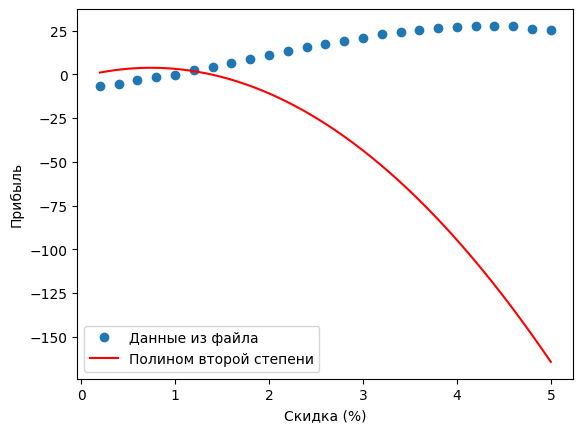

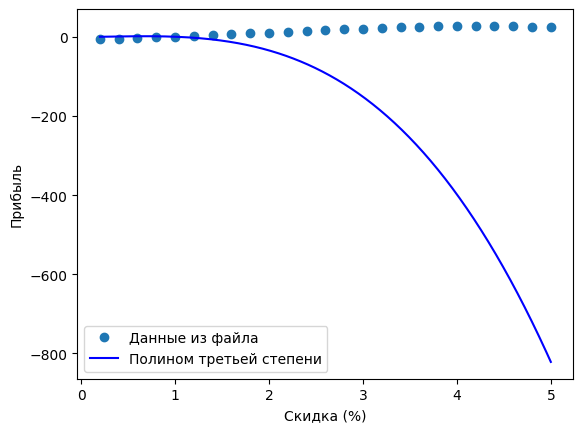

RSS для полинома второй степени: 194197.57025048265
RSS для полинома третьей степени: 2866378.7250128197
Ожидаемая прибыль при скидке 6%: -252.55816574626735
Ожидаемая прибыль при скидке 8%: -484.6949641626563


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

data = np.genfromtxt("data2.csv", delimiter=";", skip_header=1)  # предполагаем, что первая строка — заголовок
x = data[:, 0]
y = data[:, 1] 

# Шаг 1: Выбор 3 точек для полинома второй степени (по краям и середина)
x_points = [x[0], x[len(x)//2], x[-1]]
y_points = [y[0], y[len(x)//2], y[-1]]

# Формирование системы уравнений для полинома второй степени
A = np.array([[x_points[0]**2, x_points[0], 1],
              [x_points[1]**2, x_points[1], 1],
              [x_points[2]**2, x_points[2], 1]])

b = np.array([y_points[0], y_points[1], y_points[2]])

# Решение системы уравнений
coeffs_2nd_degree = solve(A, b)

# Шаг 3: Получение вектора значений полинома
f_2nd_degree = np.poly1d(coeffs_2nd_degree[::-1])  # полином второй степени

# Шаг 4: Построение графиков
x_vals = np.linspace(min(x), max(x), 500)
y_vals = f_2nd_degree(x_vals)

plt.plot(x, y, 'o', label="Данные из файла")
plt.plot(x_vals, y_vals, label="Полином второй степени", color='red')
plt.xlabel("Скидка (%)")
plt.ylabel("Прибыль")
plt.legend()
plt.show()

# Шаг 5: Расчет RSS для полинома второй степени
rss_2nd_degree = np.sum((y - f_2nd_degree(x))**2)

# Шаг 6: Повторяем для полинома третьей степени
# Выбираем 4 точки (по краям и 2 в середине)
x_points_3rd_degree = [x[0], x[len(x)//3], x[len(x)*2//3], x[-1]]
y_points_3rd_degree = [y[0], y[len(x)//3], y[len(x)*2//3], y[-1]]

A_3rd_degree = np.array([[x_points_3rd_degree[0]**3, x_points_3rd_degree[0]**2, x_points_3rd_degree[0], 1],
                          [x_points_3rd_degree[1]**3, x_points_3rd_degree[1]**2, x_points_3rd_degree[1], 1],
                          [x_points_3rd_degree[2]**3, x_points_3rd_degree[2]**2, x_points_3rd_degree[2], 1],
                          [x_points_3rd_degree[3]**3, x_points_3rd_degree[3]**2, x_points_3rd_degree[3], 1]])

b_3rd_degree = np.array([y_points_3rd_degree[0], y_points_3rd_degree[1], y_points_3rd_degree[2], y_points_3rd_degree[3]])

coeffs_3rd_degree = solve(A_3rd_degree, b_3rd_degree)

# Шаг 7: Получение вектора значений полинома третьей степени
f_3rd_degree = np.poly1d(coeffs_3rd_degree[::-1])  # полином третьей степени

# Построение графиков
y_vals_3rd_degree = f_3rd_degree(x_vals)

plt.plot(x, y, 'o', label="Данные из файла")
plt.plot(x_vals, y_vals_3rd_degree, label="Полином третьей степени", color='blue')
plt.xlabel("Скидка (%)")
plt.ylabel("Прибыль")
plt.legend()
plt.show()

# Шаг 8: Расчет RSS для полинома третьей степени
rss_3rd_degree = np.sum((y - f_3rd_degree(x))**2)

# Вывод результатов
print(f"RSS для полинома второй степени: {rss_2nd_degree}")
print(f"RSS для полинома третьей степени: {rss_3rd_degree}")

# Шаг 9: Ожидаемая прибыль при скидках 6% и 8% для лучшего полинома
best_polynomial = f_2nd_degree if rss_2nd_degree < rss_3rd_degree else f_3rd_degree
expected_profit_6 = best_polynomial(6)
expected_profit_8 = best_polynomial(8)

print(f"Ожидаемая прибыль при скидке 6%: {expected_profit_6}")
print(f"Ожидаемая прибыль при скидке 8%: {expected_profit_8}")

- Мы сначала читаем данные из CSV файла.
- Для полинома второй степени выбираем 3 точки: по одной на начальном, среднем и конечном значении диапазона.
- Для полинома третьей степени выбираем 4 точки.
- С помощью библиотеки scipy.linalg.solve решаем систему линейных уравнений для обоих полиномов.
- Строим графики и рассчитываем RSS для каждого полинома.
- Выбираем полином с наименьшим значением RSS и вычисляем ожидаемую прибыль для скидок 6% и 8%.